# Estructura del Notebook

## 1. Contexto del problema
En esta sección se describe el problema que se desea resolver, el objetivo del análisis y el contexto en el que se utilizará el modelo. Se debe explicar brevemente qué se busca predecir o analizar y por qué es relevante.

## 2. Importación de librerías
Aquí se importan todas las librerías necesarias para el análisis de datos, visualización y construcción del modelo de aprendizaje automático.

## 3. Carga del dataset
En esta sección se carga el conjunto de datos que será utilizado en el análisis. El dataset puede provenir de un archivo local (CSV, Excel, etc.) o de una fuente externa.

## 4. Exploración de datos
Se realiza una exploración inicial del dataset para entender su estructura, tipos de datos, valores faltantes y distribución general de las variables.

## 5. Identificación de valores faltantes

Antes de entrenar el modelo es necesario verificar si el dataset contiene valores
faltantes, ya que muchos algoritmos de Machine Learning no pueden procesar
valores nulos (NaN).

## 6. Tratamiento de valores faltantes

Si se detectan valores faltantes, se deberá hacer la reestructuración de los datos.

## 7. Visualización de la variable objetivo
Se analiza gráficamente la variable que se desea predecir para entender su distribución y posibles patrones.

## 8. Preprocesamiento
Se realizan las transformaciones necesarias sobre los datos, como limpieza, manejo de valores faltantes, codificación de variables categóricas o normalización.

## 9. Definición de variables
Se definen las variables independientes (features) y la variable dependiente (target) que se utilizarán para entrenar el modelo.

## 10. División Train/Test
El dataset se divide en conjuntos de entrenamiento y prueba para poder evaluar el desempeño del modelo de manera objetiva.

## 11. Entrenamiento del modelo
Se entrena el modelo de aprendizaje automático utilizando los datos de entrenamiento.

## 12. Predicciones
El modelo entrenado se utiliza para generar predicciones sobre el conjunto de prueba.

## 13. Evaluación del modelo
Se calculan métricas de evaluación que permiten medir el desempeño del modelo.

## 14. Interpretación de resultados
Se analizan los resultados obtenidos, se interpretan las métricas y se discute qué tan bien resuelve el modelo el problema planteado.

---

## Relación con los objetivos del proyecto

La estructura del Notebook sigue el flujo de trabajo solicitado en el documento del proyecto:

- **Analizar dataset** → Exploración de datos y visualización.  
- **Preparar datos** → Preprocesamiento y definición de variables.  
- **Construir modelo** → División Train/Test y entrenamiento.  
- **Evaluar desempeño** → Predicciones y evaluación del modelo.  
- **Interpretar resultados** → Análisis final de los resultados obtenidos.

---

# 1. CONTEXTO - Predicción de Finalización del Curso con Machine Learning

## Contexto

En las instituciones educativas, la analítica de datos permite identificar patrones
de comportamiento estudiantil que ayudan a detectar riesgo de deserción.

En este proyecto se desarrolla un modelo de Machine Learning que predice si
un estudiante finalizará o no un curso, utilizando datos de comportamiento
como:

- horas de conexión
- recursos vistos
- participación en foros
- nota de autoevaluación

---

# 2. Importar librería

In [41]:
# Importación de la librería pandas.
# Se utiliza para la manipulación, análisis y estructuración de datos en DataFrames.
import pandas as pd

# Importación de numpy.
# Proporciona soporte para operaciones numéricas, arreglos multidimensionales
# y funciones matemáticas de alto rendimiento.
import numpy as np


# Importación de matplotlib para visualización de datos.
# pyplot permite crear gráficos como histogramas, barras, líneas y dispersión.
import matplotlib.pyplot as plt

# Importación de seaborn.
# Biblioteca basada en matplotlib que facilita la creación de visualizaciones
# estadísticas más claras y estéticas.
import seaborn as sns


# Importación de train_test_split desde sklearn.
# Permite dividir el dataset en conjuntos de entrenamiento y prueba,
# lo cual es fundamental para evaluar el desempeño del modelo.
from sklearn.model_selection import train_test_split

# Importación de LabelEncoder.
# Se utiliza para convertir variables categóricas en valores numéricos
# que puedan ser procesados por los algoritmos de machine learning.
from sklearn.preprocessing import LabelEncoder

# Importación del modelo LogisticRegression.
# Algoritmo de clasificación supervisada utilizado principalmente
# para problemas de clasificación binaria.
from sklearn.linear_model import LogisticRegression

# Importación de métricas de evaluación del modelo.

# accuracy_score:
# Calcula la proporción de predicciones correctas respecto al total.
from sklearn.metrics import accuracy_score

# classification_report:
# Genera un reporte con métricas como precisión (precision),
# exhaustividad (recall), F1-score y soporte para cada clase.
from sklearn.metrics import classification_report

# confusion_matrix:
# Genera una matriz que permite visualizar el desempeño del modelo
# mostrando verdaderos positivos, falsos positivos,
# verdaderos negativos y falsos negativos.
from sklearn.metrics import confusion_matrix

# Importación de SimpleImputer desde sklearn.
# Esta herramienta se utiliza para manejar valores faltantes (missing values)
# en un dataset, reemplazándolos por una estrategia definida como la media,
# mediana, valor más frecuente o una constante.
from sklearn.impute import SimpleImputer

# 3. Cargar dataset

In [42]:
# Carga del dataset desde un archivo CSV utilizando la librería pandas.
# pd.read_csv() permite leer archivos separados por delimitadores y convertirlos
# en un DataFrame para su posterior análisis.

# El parámetro sep=";" indica que los datos están separados por punto y coma,
# lo cual es común en archivos CSV generados en configuraciones regionales específicas.
df = pd.read_csv("/content/comportamiento_estudiantes.csv", sep=";")

# Visualización de las primeras 5 filas del DataFrame.
# head() se utiliza para realizar una inspección rápida de la estructura del dataset,
# verificar los nombres de las columnas y observar los primeros registros cargados.
df.head()

,horas_conexion,recursos_vistos,participacion_foro,nota_auto_eval,finalizo_curso
0,10.0,93.0,Alta,2.52,1
1,7.4,83.5,Alta,3.06,1
2,10.6,66.2,Baja,2.41,0
3,14.1,52.1,Alta,2.89,0
4,7.1,79.0,Media,1.31,0


---
## 4. Exploración del dataset

En esta sección se analiza la estructura de los datos,
identificando tipos de variables y posibles valores faltantes.

In [43]:
# Muestra un resumen estructural del DataFrame.
# info() permite inspeccionar rápidamente la estructura del dataset.

# La salida incluye:
# - Número total de registros (filas).
# - Número de columnas.
# - Nombre de cada columna.
# - Tipo de dato de cada variable (int, float, object, etc.).
# - Cantidad de valores no nulos por columna.
# - Uso aproximado de memoria.

# Esta función es útil para detectar:
# - Valores faltantes (cuando los non-null son menores al total de filas).
# - Variables categóricas que aparecen como tipo "object".
# - Tipos de datos que pueden requerir transformación durante el preprocesamiento.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   horas_conexion      1000 non-null   float64
 1   recursos_vistos     938 non-null    float64
 2   participacion_foro  1000 non-null   object 
 3   nota_auto_eval      1000 non-null   float64
 4   finalizo_curso      1000 non-null   int64  
dtypes: float64(3), int64(1), object(1)
memory usage: 39.2+ KB


In [44]:
# Genera un resumen estadístico descriptivo de las variables numéricas del DataFrame.
# describe() calcula métricas estadísticas básicas que permiten entender
# la distribución de los datos.

# Entre las métricas que se muestran se encuentran:
# - count: número de valores no nulos
# - mean: media o promedio
# - std: desviación estándar
# - min: valor mínimo
# - 25%: primer cuartil
# - 50%: mediana
# - 75%: tercer cuartil
# - max: valor máximo

# Este análisis es útil para detectar:
# - posibles valores atípicos (outliers)
# - rangos de valores
# - comportamiento general de las variables numéricas
df.describe()

,horas_conexion,recursos_vistos,nota_auto_eval,finalizo_curso
count,1000.00000,938.000000,1000.000000,1000.000000
mean,8.09520,66.173241,3.191090,0.781000
std,3.85257,18.922476,0.949256,0.413776
min,0.00000,6.200000,0.180000,0.000000
25%,5.40000,53.225000,2.550000,1.000000
50%,8.10000,66.300000,3.200000,1.000000
75%,10.60000,79.400000,3.862500,1.000000
max,20.00000,100.000000,5.000000,1.000000


---

## 5. Identificación de valores faltantes

Antes de entrenar el modelo es necesario verificar si el dataset contiene valores
faltantes, ya que muchos algoritmos de Machine Learning no pueden procesar
valores nulos (NaN).

Se realiza un análisis para identificar qué columnas presentan datos faltantes.

In [45]:
# Verifica la cantidad de valores nulos en cada columna del DataFrame.
# isnull() identifica las celdas con valores faltantes (NaN)
# y sum() cuenta cuántos existen por columna.
df.isnull().sum()

,0
horas_conexion,0
recursos_vistos,62
participacion_foro,0
nota_auto_eval,0
finalizo_curso,0


---

## 6. Tratamiento de valores faltantes

Se detectaron valores faltantes en la variable **recursos_vistos**.

Para evitar perder observaciones del dataset, se utiliza la técnica de
**imputación estadística** mediante la librería `SimpleImputer` de `sklearn`.

La estrategia utilizada es **mean**, que reemplaza los valores faltantes
por la media de la variable.

In [46]:
# Creación de un imputador para manejar valores faltantes.
# strategy="mean" indica que los valores NaN serán reemplazados
# por el promedio de la columna.
imputer = SimpleImputer(strategy="mean")

# Aplicación del imputador a la columna "recursos_vistos".
# fit_transform() calcula la media de la columna y sustituye
# los valores faltantes por ese valor.
df["recursos_vistos"] = imputer.fit_transform(df[["recursos_vistos"]])

## Verificación de imputación

Se verifica nuevamente el dataset para confirmar que los valores faltantes
han sido correctamente reemplazados.

In [47]:
# Verifica la cantidad de valores nulos en cada columna del DataFrame.
# isnull() identifica las celdas con valores faltantes (NaN)
# y sum() cuenta cuántos existen por columna.
df.isnull().sum()

,0
horas_conexion,0
recursos_vistos,0
participacion_foro,0
nota_auto_eval,0
finalizo_curso,0


---

# 7. Distribución de la variable objetivo

La variable objetivo es **finalizo_curso**.
Esta variable indica si el estudiante completó o no el curso.

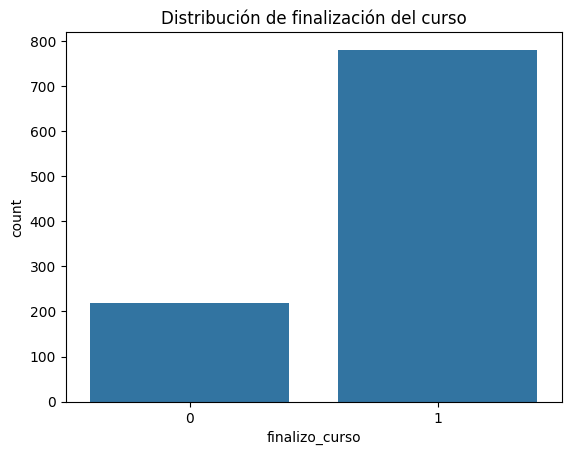

In [48]:
# Gráfico de conteo para visualizar la distribución de la variable objetivo
sns.countplot(x="finalizo_curso", data=df)

# Título del gráfico
plt.title("Distribución de finalización del curso")

# Mostrar la visualización
plt.show()

---

# 8. Preprocesamiento

La variable **participacion_foro** es categórica
(Alta, Media, Baja). Para poder usarla en el modelo
se convierte a valores numéricos mediante Label Encoding.

In [49]:
# Creación de una instancia de LabelEncoder.
# Esta herramienta de sklearn permite transformar variables categóricas
# (texto o etiquetas) en valores numéricos que pueden ser utilizados
# por algoritmos de machine learning.
le = LabelEncoder()

# Transformación de la columna "participacion_foro".
# fit_transform() realiza dos pasos:
# 1. Aprende las categorías existentes en la columna.
# 2. Asigna un valor numérico entero a cada categoría.
# Ejemplo: "Baja" -> 0, "Media" -> 1, "Alta" -> 2
df["participacion_foro"] = le.fit_transform(df["participacion_foro"])

# Visualización de las primeras filas para verificar
# que la codificación se haya aplicado correctamente.
df.head()

,horas_conexion,recursos_vistos,participacion_foro,nota_auto_eval,finalizo_curso
0,10.0,93.0,0,2.52,1
1,7.4,83.5,0,3.06,1
2,10.6,66.2,1,2.41,0
3,14.1,52.1,0,2.89,0
4,7.1,79.0,2,1.31,0


---

# 9. Definir variables

In [50]:
# Separación de variables para el modelo

# X contiene las variables independientes (features).
# Se elimina la columna "finalizo_curso" porque esta es la variable
# que se desea predecir y no debe formar parte de los datos de entrada.
X = df.drop("finalizo_curso", axis=1)

# y corresponde a la variable objetivo (target).
# Esta columna indica si el estudiante finalizó o no el curso,
# y será la salida que el modelo intentará predecir.
y = df["finalizo_curso"]

---

# 10. Dividir datos entrenamiento / prueba

In [51]:
# División del dataset en conjuntos de entrenamiento y prueba.
# train_test_split separa los datos para poder entrenar el modelo
# y posteriormente evaluar su desempeño con datos no vistos.

X_train, X_test, y_train, y_test = train_test_split(
    X,  # Variables independientes
    y,  # Variable objetivo
    test_size=0.2,  # 20% de los datos se reservan para prueba
    random_state=42  # Semilla para asegurar reproducibilidad de la división
)

---

# 11. Entrenar modelo


Se utiliza un modelo de **Regresión Logística**,
el cual es adecuado para problemas de clasificación binaria.

In [52]:
# Creación del modelo de Regresión Logística.
# Este algoritmo de clasificación supervisada se utiliza para predecir
# probabilidades de pertenencia a una clase (en este caso, si el estudiante
# finaliza o no el curso).
model = LogisticRegression()

# Entrenamiento del modelo utilizando los datos de entrenamiento.
# fit() ajusta los parámetros del modelo a partir de las variables de entrada (X_train)
# y la variable objetivo correspondiente (y_train).
model.fit(X_train, y_train)

LogisticRegression()

---

#12. Predicciones

In [53]:
# Generación de predicciones utilizando el modelo entrenado.
# predict() aplica el modelo sobre el conjunto de datos de prueba (X_test)
# para estimar la clase de la variable objetivo.
y_pred = model.predict(X_test)

# Visualización de las primeras 10 predicciones realizadas por el modelo.
y_pred[:10]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

---

#13. Evaluación del modelo

In [54]:
# Cálculo de la precisión (accuracy) del modelo.
# accuracy_score mide la proporción de predicciones correctas
# comparando los valores reales (y_test) con las predicciones del modelo (y_pred).
accuracy = accuracy_score(y_test, y_pred)

# Impresión del resultado de la métrica de precisión.
print("Accuracy del modelo:", accuracy)

Accuracy del modelo: 0.805


## Matriz de confusión

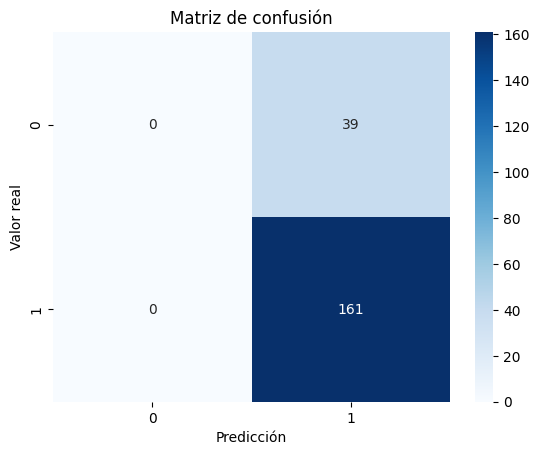

In [55]:
# Cálculo de la matriz de confusión.
# Esta matriz permite evaluar el desempeño del modelo comparando
# las predicciones realizadas con los valores reales.
cm = confusion_matrix(y_test, y_pred)

# Visualización de la matriz de confusión mediante un heatmap.
# annot=True muestra los valores dentro de cada celda.
# fmt="d" indica que los valores se muestran como enteros.
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

# Etiquetas y título del gráfico para facilitar la interpretación.
plt.title("Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Valor real")

# Mostrar la visualización
plt.show()

## Reporte de clasificación

In [56]:
# Genera un reporte de evaluación del modelo.
# Incluye métricas como precisión, recall y F1-score para cada clase.
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        39
           1       0.81      1.00      0.89       161

    accuracy                           0.81       200
   macro avg       0.40      0.50      0.45       200
weighted avg       0.65      0.81      0.72       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


---

## 14. Interpretación de resultados

El modelo permite identificar patrones de comportamiento
que influyen en la finalización del curso.

Variables como:

- mayor número de horas de conexión
- mayor número de recursos vistos
- participación activa en foros
- mejores resultados en autoevaluaciones

tienden a asociarse con una mayor probabilidad
de finalizar el curso.

Este tipo de modelos puede ayudar a las universidades
a detectar estudiantes en riesgo y aplicar estrategias
de intervención temprana.

---

## PLUS: Dashboard de predicción

## 1. Instalar widgets

In [57]:
!pip install ipywidgets

## 2. Importar librerías del dashboard

In [58]:
import ipywidgets as widgets
from IPython.display import display

## 3. Crear los controles de entrada

In [63]:
# Creación de un control deslizante (IntSlider) para capturar
# el número de horas de conexión del estudiante en la plataforma.
# Se define un rango de 0 a 15 horas con incrementos de 1.
horas_conexion = widgets.IntSlider(
    value=5,
    min=0,
    max=15,
    step=1,
    description="Horas conexión:"
)

# Slider para indicar la cantidad de recursos educativos
# que el estudiante ha visualizado dentro del curso.
recursos_vistos = widgets.IntSlider(
    value=5,
    min=0,
    max=20,
    step=1,
    description="Recursos vistos:"
)

# Menú desplegable para seleccionar el nivel de participación
# del estudiante en los foros del curso.
participacion_foro = widgets.Dropdown(
    options=["Baja","Media","Alta"],
    value="Media",
    description="Participación:"
)

# Slider de tipo flotante para ingresar la nota obtenida
# en la autoevaluación del curso. El rango va de 0 a 5.
nota_autoevaluacion = widgets.FloatSlider(
    value=3.0,
    min=0,
    max=5,
    step=0.1,
    description="Nota:"
)

# Botón que permitirá ejecutar la predicción del modelo
# utilizando los valores seleccionados en los controles.
boton_prediccion = widgets.Button(description="Predecir resultado")

# Visualización de los widgets en el Notebook
display(horas_conexion)
display(recursos_vistos)
display(participacion_foro)
display(nota_autoevaluacion)
display(boton_prediccion)

IntSlider(value=5, description='Horas conexión:', max=15)

IntSlider(value=5, description='Recursos vistos:', max=20)

Dropdown(description='Participación:', index=1, options=('Baja', 'Media', 'Alta'), value='Media')

FloatSlider(value=3.0, description='Nota:', max=5.0)

Button(description='Predecir resultado', style=ButtonStyle())


Resultado de la predicción
El estudiante probablemente FINALIZARÁ el curso
Probabilidad de finalizar: 78.82 %


## 4. Función de predicción

In [62]:
# Definición de la función que se ejecutará cuando el usuario presione
# el botón de predicción en la interfaz de widgets.
# El parámetro "b" corresponde al evento generado por el botón.
def predecir(b):

    # Diccionario que convierte las categorías de participación
    # del foro en valores numéricos, para que puedan ser procesados
    # por el modelo de machine learning.
    foro_map = {
        "Baja":0,
        "Media":1,
        "Alta":2
    }

    # Creación de un DataFrame con los valores ingresados por el usuario
    # en los widgets. Este formato debe coincidir con las variables
    # utilizadas durante el entrenamiento del modelo.
    datos = pd.DataFrame({
        "horas_conexion":[horas_conexion.value],
        "recursos_vistos":[recursos_vistos.value],
        "participacion_foro":[foro_map[participacion_foro.value]],
        "nota_auto_eval":[nota_autoevaluacion.value]
    })

    # Generación de la predicción de clase utilizando el modelo entrenado.
    prediccion = model.predict(datos)[0]

    # Obtención de la probabilidad de que el estudiante finalice el curso.
    # predict_proba devuelve la probabilidad para cada clase.
    probabilidad = model.predict_proba(datos)[0][1]

    # Interpretación del resultado de la predicción
    if prediccion == 1:
        resultado = "El estudiante probablemente FINALIZARÁ el curso"
    else:
        resultado = "El estudiante probablemente NO finalizará el curso"

    # Impresión del resultado y la probabilidad estimada
    print("\nResultado de la predicción")
    print(resultado)
    print("Probabilidad de finalizar:", round(probabilidad*100,2),"%")

## 5. Conectar el botón con el modelo

In [64]:
# Asocia el evento de clic del botón con la función `predecir`.
# Cada vez que el usuario presione el botón "Predecir resultado",
# se ejecutará la función `predecir`, la cual normalmente contiene
# la lógica para tomar los valores de los widgets y generar la predicción.
boton_prediccion.on_click(predecir)